In [1]:
import os
os.environ['PATH'] = '/home/irman/Gelochip/.venv/bin:' + os.environ.get('PATH', '')
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, '/home/irman/Gelochip/src/gelochip')

import klayout.db as kdb
import klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, out_png=None, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs):
        print(f'GDS not found: {gds_abs}'); return
    out_png = out_png or gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True)
    lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))




2026-05-18 20:35:31.710 | WARNING  | gdsfactory.pdk:get_active_pdk:733 - No active PDK. Activating generic PDK.



2026-05-18 20:35:32.069 | INFO     | gdsfactory.technology.layer_views:__init__:790 - Importing LayerViews from YAML file: '/home/irman/Gelochip/.venv/lib/python3.13/site-packages/gdsfactory/generic_tech/layer_views.yaml'.


2026-05-18 20:35:32.070 | INFO     | gdsfactory.pdk:activate:337 - 'generic' PDK is now active


2026-05-18 20:35:32.077 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


2026-05-18 20:35:36.234 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to 'dse.gds'


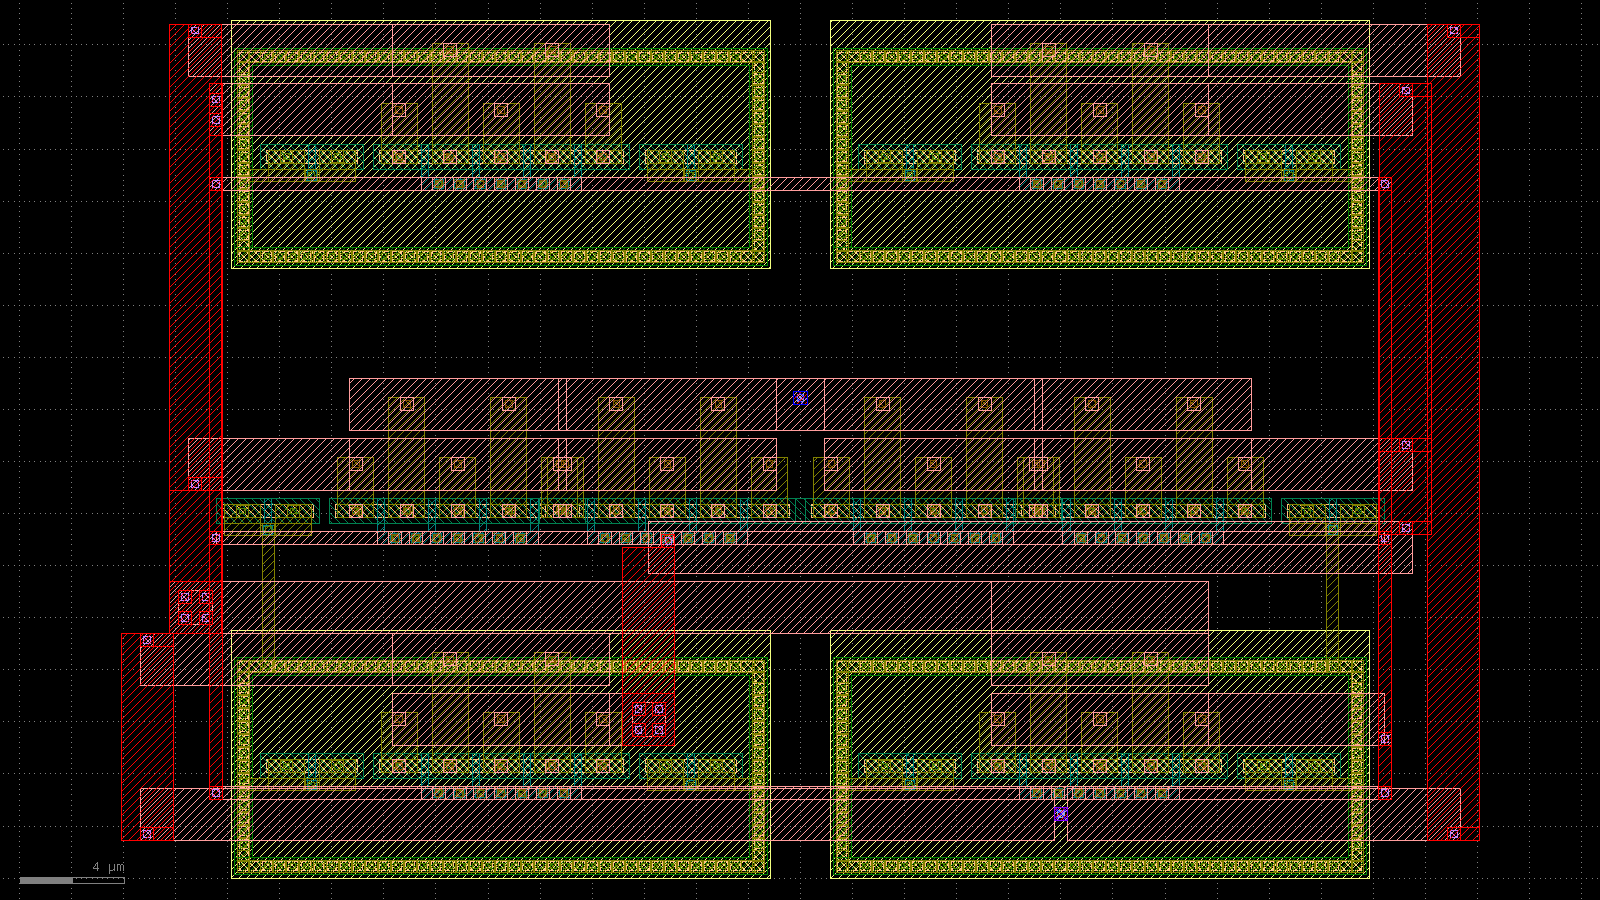

2026-05-18 20:35:36.309 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpc0mccleg/shared_gate_components$1.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 20:35:36.535 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpz5qsk234/shared_gate_components$1.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpc0mccleg/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "shared_gate_components$1".
[INF

In [2]:
import sys
try:
    cm_mod = sys.modules['glayout.cells.elementary.current_mirror.current_mirror']
    if not hasattr(cm_mod, 'orig_cmn'):
        orig_cmn = cm_mod.current_mirror_netlist
        cm_mod.orig_cmn = orig_cmn
        def patched_cmn(pdk, width, length, multipliers, fingers=1, **kwargs):
            netlist = orig_cmn(pdk, width=width, length=length, multipliers=multipliers, fingers=fingers, **kwargs)
            if 'B' in netlist.nodes:
                idx = netlist.nodes.index('B')
                netlist.nodes[idx] = 'VB'
            if 'VOUT' in netlist.nodes:
                idx = netlist.nodes.index('VOUT')
                netlist.nodes[idx] = 'VCOPY'
            return netlist
        cm_mod.current_mirror_netlist = patched_cmn
        for modname, mod in list(sys.modules.items()):
            if hasattr(mod, 'current_mirror_netlist'):
                setattr(mod, 'current_mirror_netlist', patched_cmn)
except Exception as e:
    pass

from gdsfactory.cell import cell, clear_cache
from glayout import MappedPDK
from glayout.pdk.gf180_mapped import gf180_mapped_pdk
from glayout.routing import c_route,L_route,straight_route
from gdsfactory.component import Component, copy
from gdsfactory.component_reference import ComponentReference
from gdsfactory.components.rectangle import rectangle
from glayout.pdk.mappedpdk import MappedPDK
from typing import Optional, Union
from glayout.cells.elementary.diff_pair.diff_pair import diff_pair
from glayout.primitives.fet import nmos, pmos, multiplier
from glayout.primitives.guardring import tapring
from glayout.primitives.mimcap import mimcap_array, mimcap
from glayout.primitives.via_gen import via_stack, via_array
from gdsfactory.routing.route_quad import route_quad
from glayout.util.comp_utils import evaluate_bbox, prec_ref_center, movex, movey, to_decimal, to_float, move, align_comp_to_port, get_padding_points_cc
from glayout.util.port_utils import rename_ports_by_orientation, rename_ports_by_list, add_ports_perimeter, print_ports, set_port_orientation, rename_component_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.placement.two_transistor_interdigitized import two_nfet_interdigitized
from glayout.spice import Netlist



def __create_sharedgatecomps(pdk: MappedPDK, rmult: int, half_pload: tuple[float,float,int]) -> tuple:
    # add diffpair current mirror loads (this is a pmos current mirror split into 2 for better matching/compensation)
    shared_gate_comps = Component("shared gate components")
    # create the 2*2 multiplier transistors (placed twice later)
    twomultpcomps = Component("2 multiplier shared gate comps")
    pcompR = multiplier(pdk, "p+s/d", width=half_pload[0], length=half_pload[1], fingers=half_pload[2], dummy=True,rmult=rmult).copy()
    tapref = pcompR << tapring(pdk, evaluate_bbox(pcompR,padding=0.3+pdk.get_grule("n+s/d", "active_tap")["min_enclosure"]),"n+s/d","met1","met1")
    pcompR.add_padding(layers=(pdk.get_glayer("nwell"),), default=pdk.get_grule("active_tap", "nwell")["min_enclosure"])
    pcompR.add_ports(tapref.get_ports_list(),prefix="welltap_")
    pcompR << straight_route(pdk,pcompR.ports["dummy_L_gsdcon_top_met_W"],pcompR.ports["welltap_W_top_met_W"],glayer2="met1")
    pcompR << straight_route(pdk,pcompR.ports["dummy_R_gsdcon_top_met_W"],pcompR.ports["welltap_E_top_met_E"],glayer2="met1")
    pcompL = pcompR.copy()
    pcomp_AB_spacing = max(2*pdk.util_max_metal_seperation() + 6*pdk.get_grule("met4")["min_width"],pdk.get_grule("p+s/d")["min_separation"])
    _prefL = (twomultpcomps << pcompL).movex(-1 * pcompL.xmax - pcomp_AB_spacing/2)
    _prefR = (twomultpcomps << pcompR).movex(-1 * pcompR.xmin + pcomp_AB_spacing/2)
    twomultpcomps.add_ports(_prefL.get_ports_list(),prefix="L_")
    twomultpcomps.add_ports(_prefR.get_ports_list(),prefix="R_")
    twomultpcomps << route_quad(_prefL.ports["gate_W"], _prefR.ports["gate_E"], layer=pdk.get_glayer("met2"))
    # center
    relative_dim_comp = multiplier(
        pdk, "p+s/d", width=half_pload[0], length=half_pload[1], fingers=4, dummy=False, rmult=rmult
    )
    # TODO: figure out single dim spacing rule then delete both test delete and this
    single_dim = to_decimal(relative_dim_comp.xmax) + to_decimal(0.11) + to_decimal(half_pload[1])/2
    LRplusdopedPorts = list()
    LRgatePorts = list()
    LRdrainsPorts = list()
    LRsourcesPorts = list()
    LRdummyports = list()
    for i in [-2, -1, 1, 2]:
        dummy = False
        appenddummy = None
        extra_t = 0
        if i == -2:
            dummy = [True, False]
            appenddummy="L"
            pcenterfourunits = multiplier(
                pdk, "p+s/d", width=half_pload[0], length=half_pload[1], fingers=4, dummy=dummy, rmult=rmult
            )
            extra_t = -1 * single_dim
        elif i == 2:
            dummy = [False, True]
            appenddummy="R"
            pcenterfourunits = multiplier(
                pdk, "p+s/d", width=half_pload[0], length=half_pload[1], fingers=4, dummy=dummy, rmult=rmult
            )
            extra_t = single_dim
        else:
            pcenterfourunits = relative_dim_comp
        pref_ = prec_ref_center(pcenterfourunits).movex(pdk.snap_to_2xgrid(to_float(i * single_dim + extra_t)))
        shared_gate_comps.add(pref_)
        if appenddummy:
            LRdummyports+= [pref_.ports["dummy_"+appenddummy+"_gsdcon_top_met_N"]]
        LRplusdopedPorts += [pref_.ports["plusdoped_W"] , pref_.ports["plusdoped_E"]]
        LRgatePorts += [pref_.ports["gate_W"],pref_.ports["gate_E"]]
        LRdrainsPorts += [pref_.ports["source_W"],pref_.ports["source_E"]]
        LRsourcesPorts += [pref_.ports["drain_W"],pref_.ports["drain_E"]]
    # combine the two multiplier top and bottom with the 4 multiplier center row
    ytranslation_pcenter = 2 * pcenterfourunits.ymax + 5*pdk.util_max_metal_seperation()
    ptop_AB = (shared_gate_comps << twomultpcomps).movey(ytranslation_pcenter)
    pbottom_AB = (shared_gate_comps << twomultpcomps).movey(-1 * ytranslation_pcenter)

    return shared_gate_comps, ptop_AB, pbottom_AB, LRplusdopedPorts, LRgatePorts, LRdrainsPorts, LRsourcesPorts, LRdummyports



def __route_sharedgatecomps(pdk: MappedPDK, shared_gate_comps, via_location, ptop_AB, pbottom_AB, LRplusdopedPorts, LRgatePorts, LRdrainsPorts, LRsourcesPorts,LRdummyports) -> Component:
    _max_metal_seperation_ps = pdk.util_max_metal_seperation()
    # ground dummy transistors of the 4 center multipliers
    shared_gate_comps << straight_route(pdk,LRdummyports[0],pbottom_AB.ports["L_welltap_N_top_met_S"],glayer2="met1")
    shared_gate_comps << straight_route(pdk,LRdummyports[1],pbottom_AB.ports["R_welltap_N_top_met_S"],glayer2="met1")
    # connect p+s/d layer of the transistors
    shared_gate_comps << route_quad(LRplusdopedPorts[0],LRplusdopedPorts[-1],layer=pdk.get_glayer("p+s/d"))
    # connect drain of the left 2 and right 2, short sources of all 4
    shared_gate_comps << route_quad(LRdrainsPorts[0],LRdrainsPorts[3],layer=LRdrainsPorts[0].layer)
    shared_gate_comps << route_quad(LRdrainsPorts[4],LRdrainsPorts[7],layer=LRdrainsPorts[0].layer)
    shared_gate_comps << route_quad(LRsourcesPorts[0],LRsourcesPorts[-1],layer=LRsourcesPorts[0].layer)
    pcomps_2L_2R_sourcevia = shared_gate_comps << via_stack(pdk,pdk.layer_to_glayer(LRsourcesPorts[0].layer), "met4")
    pcomps_2L_2R_sourcevia.movey(evaluate_bbox(pcomps_2L_2R_sourcevia.parent.extract(layers=[LRsourcesPorts[0].layer,]))[1]/2 + LRsourcesPorts[0].center[1])
    shared_gate_comps.add_ports(pcomps_2L_2R_sourcevia.get_ports_list(),prefix="2L2Rsrcvia_")
    # short all the gates
    shared_gate_comps << route_quad(LRgatePorts[0],LRgatePorts[-1],layer=pdk.get_glayer("met2"))
    shared_gate_comps.add_ports(ptop_AB.get_ports_list(),prefix="ptopAB_")
    shared_gate_comps.add_ports(pbottom_AB.get_ports_list(),prefix="pbottomAB_")
    # short all gates of shared_gate_comps
    pcenter_gate_route_extension = pdk.snap_to_2xgrid(shared_gate_comps.xmax - min(ptop_AB.ports["R_gate_E"].center[0], LRgatePorts[-1].center[0]) - pdk.get_grule("active_diff")["min_width"])
    pcenter_l_croute = shared_gate_comps << c_route(pdk, ptop_AB.ports["L_gate_W"], pbottom_AB.ports["L_gate_W"],extension=pcenter_gate_route_extension)
    pcenter_r_croute = shared_gate_comps << c_route(pdk, ptop_AB.ports["R_gate_E"], pbottom_AB.ports["R_gate_E"],extension=pcenter_gate_route_extension)
    shared_gate_comps << straight_route(pdk, LRgatePorts[0], pcenter_l_croute.ports["con_N"])
    shared_gate_comps << straight_route(pdk, LRgatePorts[-1], pcenter_r_croute.ports["con_N"])
    # connect drain of A to the shorted gates
    shared_gate_comps << L_route(pdk,ptop_AB.ports["L_source_W"],pcenter_l_croute.ports["con_N"])
    shared_gate_comps << straight_route(pdk,pbottom_AB.ports["R_source_E"],pcenter_r_croute.ports["con_N"])
    # connect source of A to the drain of 2L
    pcomps_route_A_drain_extension = shared_gate_comps.xmax-max(ptop_AB.ports["R_drain_E"].center[0], LRdrainsPorts[-1].center[0])+_max_metal_seperation_ps
    pcomps_route_A_drain = shared_gate_comps << c_route(pdk, ptop_AB.ports["L_drain_W"], LRdrainsPorts[0], extension=pcomps_route_A_drain_extension)
    row_rectangle_routing = rectangle(layer=ptop_AB.ports["L_drain_W"].layer,size=(pbottom_AB.ports["R_source_N"].width,pbottom_AB.ports["R_source_W"].width)).copy()
    Aextra_top_connection = align_comp_to_port(row_rectangle_routing, pbottom_AB.ports["R_source_N"], ('c','t')).movey(row_rectangle_routing.ymax + _max_metal_seperation_ps)
    shared_gate_comps.add(Aextra_top_connection)
    shared_gate_comps << straight_route(pdk,Aextra_top_connection.ports["e4"],pbottom_AB.ports["R_drain_N"])
    shared_gate_comps << L_route(pdk,pcomps_route_A_drain.ports["con_S"], Aextra_top_connection.ports["e1"],viaoffset=(False,True))
    # connect source of B to drain of 2R
    pcomps_route_B_source_extension = shared_gate_comps.xmax-max(LRsourcesPorts[-1].center[0],ptop_AB.ports["R_source_E"].center[0])+_max_metal_seperation_ps
    mimcap_connection_ref = shared_gate_comps << c_route(pdk, ptop_AB.ports["R_source_E"], LRdrainsPorts[-1],extension=pcomps_route_B_source_extension,viaoffset=(True,False))
    bottom_pcompB_floating_port = set_port_orientation(movey(movex(pbottom_AB.ports["L_source_E"].copy(),5*_max_metal_seperation_ps), destination=Aextra_top_connection.ports["e1"].center[1]+Aextra_top_connection.ports["e1"].width+_max_metal_seperation_ps),"S")
    pmos_bsource_2Rdrain_v = shared_gate_comps << L_route(pdk,pbottom_AB.ports["L_source_E"],bottom_pcompB_floating_port,vglayer="met3")
    # fix the extension when the top row of transistors extends farther than the middle row
    if LRdrainsPorts[-1].center[0] < ptop_AB.ports["R_source_E"].center[0]:
        pcomps_route_B_source_extension += ptop_AB.ports["R_source_E"].center[0] - LRdrainsPorts[-1].center[0]
    shared_gate_comps << c_route(pdk, LRdrainsPorts[-1], set_port_orientation(bottom_pcompB_floating_port,"E"),extension=pcomps_route_B_source_extension,viaoffset=(True,False))
    pmos_bsource_2Rdrain_v_center = via_stack(pdk,"met2","met3",fulltop=True)
    shared_gate_comps.add(align_comp_to_port(pmos_bsource_2Rdrain_v_center, bottom_pcompB_floating_port,('r','t')))
    # connect drain of B to each other directly over where the diffpair top left drain will be
    pmos_bdrain_diffpair_v = shared_gate_comps << via_stack(pdk, "met2","met5",fullbottom=True)
    pmos_bdrain_diffpair_v = align_comp_to_port(pmos_bdrain_diffpair_v, movex(pbottom_AB.ports["L_gate_S"].copy(),destination=via_location))
    pmos_bdrain_diffpair_v.movey(0-_max_metal_seperation_ps)
    pcomps_route_B_drain_extension = shared_gate_comps.xmax-ptop_AB.ports["R_drain_E"].center[0]+_max_metal_seperation_ps
    shared_gate_comps << c_route(pdk, ptop_AB.ports["R_drain_E"], pmos_bdrain_diffpair_v.ports["bottom_met_E"],extension=pcomps_route_B_drain_extension +_max_metal_seperation_ps)
    shared_gate_comps << c_route(pdk, pbottom_AB.ports["L_drain_W"], pmos_bdrain_diffpair_v.ports["bottom_met_W"],extension=pcomps_route_B_drain_extension +_max_metal_seperation_ps)
    shared_gate_comps.add_ports(pmos_bdrain_diffpair_v.get_ports_list(),prefix="minusvia_")
    shared_gate_comps.add_ports(mimcap_connection_ref.get_ports_list(),prefix="mimcap_connection_")
    return shared_gate_comps

def differential_to_single_ended_converter_netlist(pdk: MappedPDK, half_pload: tuple[float, float, int]) -> Netlist:
    return Netlist(
        circuit_name="DIFF_TO_SINGLE",
        nodes=['VIN', 'VOUT', 'VSS', 'VSS2'],
        source_netlist=""".subckt {circuit_name} {nodes} """ + f'l={half_pload[1]} w={half_pload[0]} mt={4*2} mb={2 * half_pload[2]} ' + """
XTOP1 V1   VIN VSS  VSS {model} l={{l}} w={{w}} m={{mt}}
XTOP2 VSS2 VIN VSS  VSS {model} l={{l}} w={{w}} m={{mt}}
XBOT1 VIN  VIN V1   VSS {model} l={{l}} w={{w}} m={{mb}}
XBOT2 VOUT VIN VSS2 VSS {model} l={{l}} w={{w}} m={{mb}}
.ends {circuit_name}""",
        instance_format="X{name} {nodes} {circuit_name} l={length} w={width} mt={mult_top} mb={mult_bot}",
        parameters={
            'model': pdk.models['pfet'],
            'width': half_pload[0],
            'length': half_pload[1],
            'mult_top': 4 * 2,
            'mult_bot': 2 * (half_pload[2])
        }
    )

def differential_to_single_ended_converter(pdk: MappedPDK, rmult: int, half_pload: tuple[float,float,int], via_xlocation) -> Component:
    clear_cache()
    pmos_comps, ptop_AB, pbottom_AB, LRplusdopedPorts, LRgatePorts, LRdrainsPorts, LRsourcesPorts, LRdummyports = __create_sharedgatecomps(pdk, rmult,half_pload)
    clear_cache()
    pmos_comps = __route_sharedgatecomps(pdk, pmos_comps, via_xlocation, ptop_AB, pbottom_AB, LRplusdopedPorts, LRgatePorts, LRdrainsPorts, LRsourcesPorts, LRdummyports)

    pmos_comps.info['netlist'] = differential_to_single_ended_converter_netlist(pdk, half_pload)

    return pmos_comps

# Create and evaluate a dse instance
if __name__ == "__main__":
    dse = differential_to_single_ended_converter(
        pdk=gf180_mapped_pdk, 
        rmult=4, 
        half_pload=(0.5, 0.18, 4), 
        via_xlocation=10
    )
    pass # dse.show()
    dse = component_snap_to_grid(dse)
    dse_gds = dse.write_gds("dse.gds")
    

# Show the generated GDS
show_gds("dse.gds")

comp = dse
# DRC with magic (graceful if magic not installed)
try:
    drc_result = gf180_mapped_pdk.drc_magic(comp, comp.name)
    print('DRC:', drc_result)
except Exception as e:
    print(f'DRC skipped: {e}')
# LVS with netgen (graceful if netgen not installed)
try:
    lvs_result = gf180_mapped_pdk.lvs_netgen(comp, comp.name)
    print('LVS:', lvs_result['result_str'])
except Exception as e:
    print(f'LVS skipped: {e}')


In [3]:
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None

if run_evaluation is not None:
    result = run_evaluation("dse.gds", dse.name, dse)
    print(result)


2026-05-18 20:35:36.691 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/datasets/differential_to_single_ended_converter/SHARED_GATE_COMPONENTS.gds'


--- Starting Comprehensive Evaluation for shared_gate_components$1 ---
Cleaning up intermediate files for component 'shared_gate_components$1'...
  - Deleted directory: shared_gate_components$1_drc_out
  - Deleted directory: shared_gate_components$1_lvs_out
Running verification checks (DRC, LVS)...
using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 20:35:36.931 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp946pubad/SHARED_GATE_COMPONENTS.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmp9p3qt9vo/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "SHARED_GATE_COMPONENTS".
[INFO]

Netgen 1.5.272 compiled on Mon May 18 06:54:31 AM WIB 2026
Reading netlist file /tmp/tmp946pubad/SHARED_GATE_COMPONENTS_lvsmag.spice
Call to undefined subcircuit pfet_03v3
Creating placeholder cell definition.
Reading netlist file /tmp/tmp946pubad/SHARED_GATE_COMPONENTS.spice
Call to undefined subcircuit pmos_3p3
Creating placeholder cell definition.
Call to undefined subcircuit nmos_3p3
Creating placeholder cell definition.
Call to undefined subcircuit pfet_03v3
Creating placeholder cell definition.

Reading setup file /home/irman/pdks/gf180mcuD/libs.tech/netgen/gf180mcuD_setup.tcl

No property area found for device c
Model pfet_03v3 pin 1 == 3
No property par1 found for device pfet_03v3
No property NRD found for device pfet_03v3
No property NRS found for device pfet_03v3
No property par found for device pfet_03v3
No property sa found for device pfet_03v3
No property sb found for device pfet_03v3
No property sd found for device pfet_03v3
No property par found for device pfet_03v3
No p

--- Evaluation complete. Results saved to shared_gate_components$1_2.json ---
{'component_name': 'shared_gate_components$1', 'timestamp': '2026-05-18T20:35:38.412111', 'drc_lvs_fail': True, 'drc': {'status': 'fail', 'is_pass': False, 'report_path': '/home/irman/Gelochip/notebooks/datasets/differential_to_single_ended_converter/SHARED_GATE_COMPONENTS_drc_out/drc/SHARED_GATE_COMPONENTS/SHARED_GATE_COMPONENTS.rpt', 'summary': {'is_pass': False, 'total_errors': 165, 'error_details': [{'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '0.940um -2.035um 1.060um -2.020um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '1.060um -2.035um 1.320um -2.020um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '1.320um -2.035um 1.440um -2.020um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '0.940um -2.155um 1.440um -2.035um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '2.900um -2.035um 3.020um -2.020um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'detai

In [4]:
# ── SPICE Simulation with gf180 PDK models ─────────────────────────────────
import subprocess, os, re, tempfile

_GF180_MODELS = '/home/irman/Gelochip/src/gelochip/glayout/spice/gf180_typical.spice'

class _StringNetlist:
    def __init__(self, spice_str):
        import re as _re
        self._spice = spice_str
        # Use the LAST .subckt definition (top-level circuit)
        matches = list(_re.finditer(r'\.subckt\s+(\w+)\s+(.*)', spice_str, _re.IGNORECASE))
        if matches:
            m = matches[-1]
            self.circuit_name = m.group(1)
            # Filter out parameter-style tokens (containing =)
            self.nodes = [n for n in m.group(2).split() if '=' not in n]
        else:
            self.circuit_name = 'UNKNOWN'; self.nodes = []
    def generate_netlist(self): return self._spice

def _get_netlist(comp):
    if not hasattr(comp, 'info'): return None
    nl = comp.info.get('netlist_obj')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    nl = comp.info.get('netlist')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    if isinstance(nl, str) and nl.strip(): return _StringNetlist(nl)
    return None

def _fix_spice(spice):
    spice = re.sub(r'm=\{(\d+)\}', lambda x: f'm={x.group(1)}', spice)
    # Resolve l={expr}/w={expr} parameter placeholders to defaults
    spice = re.sub(r'\bl=\{[^}]+\}', 'l=0.28', spice)
    spice = re.sub(r'\bw=\{[^}]+\}', 'w=0.28', spice)
    # Clamp l/w to gf180 minimum valid values (in µm) to stay within model bins
    def _clamp_l(m):
        try: v = float(m.group(1)); return f'l={max(v, 0.28)}'
        except: return m.group(0)
    def _clamp_w(m):
        try: v = float(m.group(1)); return f'w={max(v, 0.22)}'
        except: return m.group(0)
    spice = re.sub(r'\bl=([\d.]+)', _clamp_l, spice)
    spice = re.sub(r'\bw=([\d.]+)', _clamp_w, spice)
    # Remove mimcap lines (not in gf180 model file)
    spice = re.sub(r'^.*mimcap.*$', '* mimcap removed', spice, flags=re.MULTILINE | re.IGNORECASE)
    return spice

def _build_testbench(name, nodes, vdd=3.3):
    nmap = {}
    for n in nodes:
        u = n.upper()
        if u in ('VDD', 'AVDD', 'VCC'): nmap[n] = 'vdd'
        elif u in ('VSS', 'GND', 'AVSS'): nmap[n] = '0'
        elif u in ('VB', 'VBULK', 'BULK', 'B'): nmap[n] = '0'
        else: nmap[n] = f'n_{n.lower()}'
    lines = [f'VDD vdd 0 DC {vdd}V']
    for n in nodes:
        u, c = n.upper(), nmap[n]
        if c in ('vdd', '0'): continue
        if any(k in u for k in ('INP', 'VINP', 'VP')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.55:.3f}')
        elif any(k in u for k in ('INM', 'VINM', 'VN')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.45:.3f}')
        elif any(k in u for k in ('IBIAS','NBC_','NB_10U','NB_','BIAS','DIFFPAIR_BIAS','CS_BIAS')):
            lines.append(f'I_{n} vdd {c} DC 10u')
        elif u == 'VREF':
            lines.append(f'Iref_{n} vdd {c} DC 10u')
        elif u in ('VOUT','OUTPUT','OUT','CSOUTPUT') or u.startswith('VOUT'):
            lines.append(f'RL_{n} vdd {c} 100k')
        elif u == 'VIN':
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
        elif u == 'VGN':
            lines.append(f'V_{n} {c} 0 DC {vdd:.3f}')
        elif u == 'VGP':
            lines.append(f'V_{n} {c} 0 DC 0')
        else:
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
    inst = ' '.join(nmap[n] for n in nodes)
    lines += [f'XDUT {inst} {name}', '.op',
              '.options GMIN=1e-12 RELTOL=1e-3 ITL1=500', '.save all']
    return '\n'.join(lines)

def run_spice_gf180(comp, label=''):
    nl = _get_netlist(comp)
    if nl is None:
        print(f'No netlist in {label or "component"}.info')
        return
    spice = _fix_spice(nl.generate_netlist())
    name = nl.circuit_name
    nodes = list(nl.nodes)
    print(f'Circuit : {name}')
    print(f'Nodes   : {nodes}')
    tb = _build_testbench(name, nodes)
    full = f'* {label or name}\n.include "{_GF180_MODELS}"\n\n{spice}\n\n{tb}\n.end\n'
    with tempfile.NamedTemporaryFile(mode='w', suffix='.sp', delete=False, dir='/tmp') as f:
        f.write(full); sp = f.name
    out_f = sp + '.out'
    try:
        r = subprocess.run(['ngspice', '-b', '-o', out_f, sp],
                           capture_output=True, text=True, timeout=60)
        raw = open(out_f).read() if os.path.exists(out_f) else r.stdout + r.stderr
        print(f'\n── DC Operating Point: {label or name} ──')
        in_tbl = False
        for line in raw.split('\n'):
            l = line.strip()
            if re.match(r'node\b.*voltage', l, re.I): in_tbl = True; print(f'\n{line}')
            elif in_tbl and re.match(r'-{3,}', l): print(line)
            elif in_tbl and not l: in_tbl = False
            elif in_tbl: print(line)
        no_conv = 'no convergence' in raw.lower()
        if r.returncode == 0 and not no_conv:
            print('\n\u2713 Converged \u2013 gf180 typical corner')
        elif no_conv:
            print('\n\u26a0 No convergence')
        else:
            errs = [l for l in raw.split('\n') if 'error' in l.lower() and l.strip()]
            print(f'\n\u26a0 ngspice exit {r.returncode}')
            for e in errs[:3]: print(f'  {e}')
    except Exception as e:
        print(f'Simulation error: {e}')
    finally:
        for fn in [sp, out_f]:
            try: os.unlink(fn)
            except: pass

run_spice_gf180(dse, label='dse')


Circuit : DIFF_TO_SINGLE
Nodes   : ['VIN', 'VOUT', 'VSS', 'VSS2']

── DC Operating Point: dse ──

	Node                                  Voltage
	----                                  -------
	----	-------
	xdut.v1                          3.028511e-01
	n_vss2                           1.650000e+00
	n_vout                           5.087737e-01
	n_vin                            1.650000e+00
	vdd                              3.300000e+00

✓ Converged – gf180 typical corner
